In [11]:
# ====================================
# 1점 리뷰 심층 분석
# ====================================

# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'NanumGothic'  # 또는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# NLP 라이브러리
from collections import Counter
import re
from wordcloud import WordCloud

# 시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 로딩 완료!")
print(f"📊 pandas 버전: {pd.__version__}")
print(f"📊 numpy 버전: {np.__version__}")

✅ 라이브러리 로딩 완료!
📊 pandas 버전: 3.0.0
📊 numpy 버전: 2.3.5


In [3]:
# ====================================
# 데이터 로드
# ====================================

# 1+2점 리뷰 데이터 로드
one_star_path = r'C:\Users\안심존_서초운영1\Documents\Woo\2025_ICB\Olist_project\data\review_ko\one_star_reviews_translated_begin2017.csv'
two_star_path = r'C:\Users\안심존_서초운영1\Documents\Woo\2025_ICB\Olist_project\data\review_ko\two_star_reviews_claude_begin2017.csv'
df_1 = pd.read_csv(one_star_path)
df_2 = pd.read_csv(two_star_path)


print("\n" + "="*60)
print("📂 1점 리뷰 번역 데이터 로드 완료!")
print("="*60)
print(f"📊 총 리뷰 수: {len(df_1):,}건")
print(f"📊 컬럼: {list(df_1.columns)}")

print("\n" + "="*60)
print("📂 2점 리뷰 번역 데이터 로드 완료!")
print("="*60)
print(f"📊 총 리뷰 수: {len(df_2):,}건")
print(f"📊 컬럼: {list(df_2.columns)}")


📂 1점 리뷰 번역 데이터 로드 완료!
📊 총 리뷰 수: 7,130건
📊 컬럼: ['order_id', 'review_comment_title', 'review_comment_message', 'message_ko', 'title_ko', 'order_purchase_timestamp']

📂 2점 리뷰 번역 데이터 로드 완료!
📊 총 리뷰 수: 1,945건
📊 컬럼: ['order_id', 'review_comment_message', 'message_ko', 'order_purchase_timestamp']


In [21]:
# ====================================
# 1. 부족한 날짜 정보 불러오기 (Merge 준비)
# ====================================
import pandas as pd

# (1) 1점과 2점 리뷰 데이터 하나로 합치기
df_low_reviews = pd.concat([df_1, df_2], ignore_index=True)

# (2) 날짜 정보가 들어있는 원본 파일들 로드
base_path = r'C:\Users\안심존_서초운영1\Documents\Woo\2025_ICB\Olist_project'
orders_path = f'{base_path}\data\processed_v2\olist_orders_dataset.csv'
reviews_raw_path = f'{base_path}\data\processed_v2\olist_order_reviews_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_reviews_raw = pd.read_csv(reviews_raw_path)

# (3) 시계열 데이터(datetime)로 변환
# 실제 리뷰 작성 시점인 'review_answer_timestamp' 사용
df_reviews_raw['review_answer_timestamp'] = pd.to_datetime(df_reviews_raw['review_answer_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

# ====================================
# 2. 데이터 결합 (Merge)
# ====================================
# step1: 리뷰 번역 데이터에 '실제 리뷰 작성 시점(answer_timestamp)' 결합
df_review_dates = df_reviews_raw[['order_id', 'review_answer_timestamp']].drop_duplicates('order_id')
df_final = pd.merge(df_low_reviews, df_review_dates, on='order_id', how='left')

# step2: 주문 정보(배송 완료일, 배송 예정일) 결합
df_final = pd.merge(
    df_final, 
    df_orders[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date']], 
    on='order_id', 
    how='left'
)

# ====================================
# 3. 실제 작성 시점 기준 그룹 분류 (Grouping)
# ====================================
def categorize_group(row):
    # 실제 리뷰 작성 시점
    review_at = row['review_answer_timestamp']
    # 실제 배송 완료 시점
    delivered_at = row['order_delivered_customer_date']
    # 배송 예정일(기한)
    estimated_at = row['order_estimated_delivery_date']
    
    if pd.isna(review_at):
        return 'Unknown'
    
    # 배송 완료 전 작성
    if review_at < delivered_at:
        if review_at <= estimated_at:
            return 'Group A-1: Pre-Delivery (ETA 내)'   # 기다리는 중
        else:
            return 'Group A-2: Pre-Delivery (ETA 초과)'  # 약속 어기고 배송도 없음

    # 배송 완료 후 작성 — 지연
    if delivered_at > estimated_at:
        return 'Group C: Delayed Delivery'

    # 배송 완료 후 작성 — 정상
    return 'Group B: On-time/Early Delivery'


df_final['delivery_group'] = df_final.apply(categorize_group, axis=1)

# 결과 확인
print("\n" + "="*60)
print("✅ 실제 리뷰 작성 시점 기준 그룹 분류 완료!")
print("="*60)
print(df_final['delivery_group'].value_counts())
print("-" * 60)
display(df_final[['order_id', 'message_ko', 'delivery_group', 'review_answer_timestamp', 'order_delivered_customer_date']].head())



✅ 실제 리뷰 작성 시점 기준 그룹 분류 완료!
delivery_group
Group B: On-time/Early Delivery     6208
Group A-2: Pre-Delivery (ETA 초과)    2475
Group C: Delayed Delivery            361
Group A-1: Pre-Delivery (ETA 내)       31
Name: count, dtype: int64
------------------------------------------------------------


,order_id,message_ko,delivery_group,review_answer_timestamp,order_delivered_customer_date
0,e6ce16cb79ec1d90b1da9085a6118aeb,매장에서 반품을 기다리는 중,Group B: On-time/Early Delivery,2017-05-30 23:13:47,2017-05-29 11:18:31
1,acce194856392f074dbf9dada14d8d82,지금까지 유아용 침대용 매트리스 보호대 - 방수 면 제품을 받지 못했습니다. 이미 ...,Group B: On-time/Early Delivery,2018-06-20 11:38:22,2018-06-16 15:20:55
2,1790eea0b567cf50911c057cf20f90f9,광고 설명에 나열된 모든 액세서리가 함께 제공되지 않을 뿐만 아니라 내가 구매한 제...,Group B: On-time/Early Delivery,2018-05-08 23:47:22,2018-05-05 12:28:34
3,6ea2f835b4556291ffdc53fa0b3b95e8,당초 구매당시 12/21까지 상품 배송 예정이었습니다.오늘이 12/27인데 아직 도...,Group A-2: Pre-Delivery (ETA 초과),2017-12-28 11:25:32,2017-12-28 18:59:23
4,6ebaec694d7025e2ad4a05dba887c032,욕조가 깨져서 도착했어요.바로크 공연은 어떻게 하나요?,Group B: On-time/Early Delivery,2017-05-31 13:34:59,2017-05-29 12:47:20


In [17]:
df_final['complaint_category']

0        배송 지연
1       배송 미수령
2       기타/미분류
3       기타/미분류
4       기타/미분류
         ...  
9070    기타/미분류
9071     고객 응대
9072     제품 품질
9073    배송 미수령
9074    기타/미분류
Name: complaint_category, Length: 9075, dtype: str

In [ ]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 9075 entries, 0 to 9074
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       9075 non-null   str           
 1   review_comment_title           1482 non-null   str           
 2   review_comment_message         9075 non-null   str           
 3   message_ko                     9074 non-null   str           
 4   title_ko                       1477 non-null   str           
 5   order_purchase_timestamp       9075 non-null   str           
 6   review_answer_timestamp        9075 non-null   datetime64[us]
 7   order_delivered_customer_date  9075 non-null   datetime64[us]
 8   order_estimated_delivery_date  9075 non-null   datetime64[us]
 9   delivery_group                 9075 non-null   str           
 10  complaint_category             9075 non-null   str           
dtypes: datetime64[us](3), str(8)

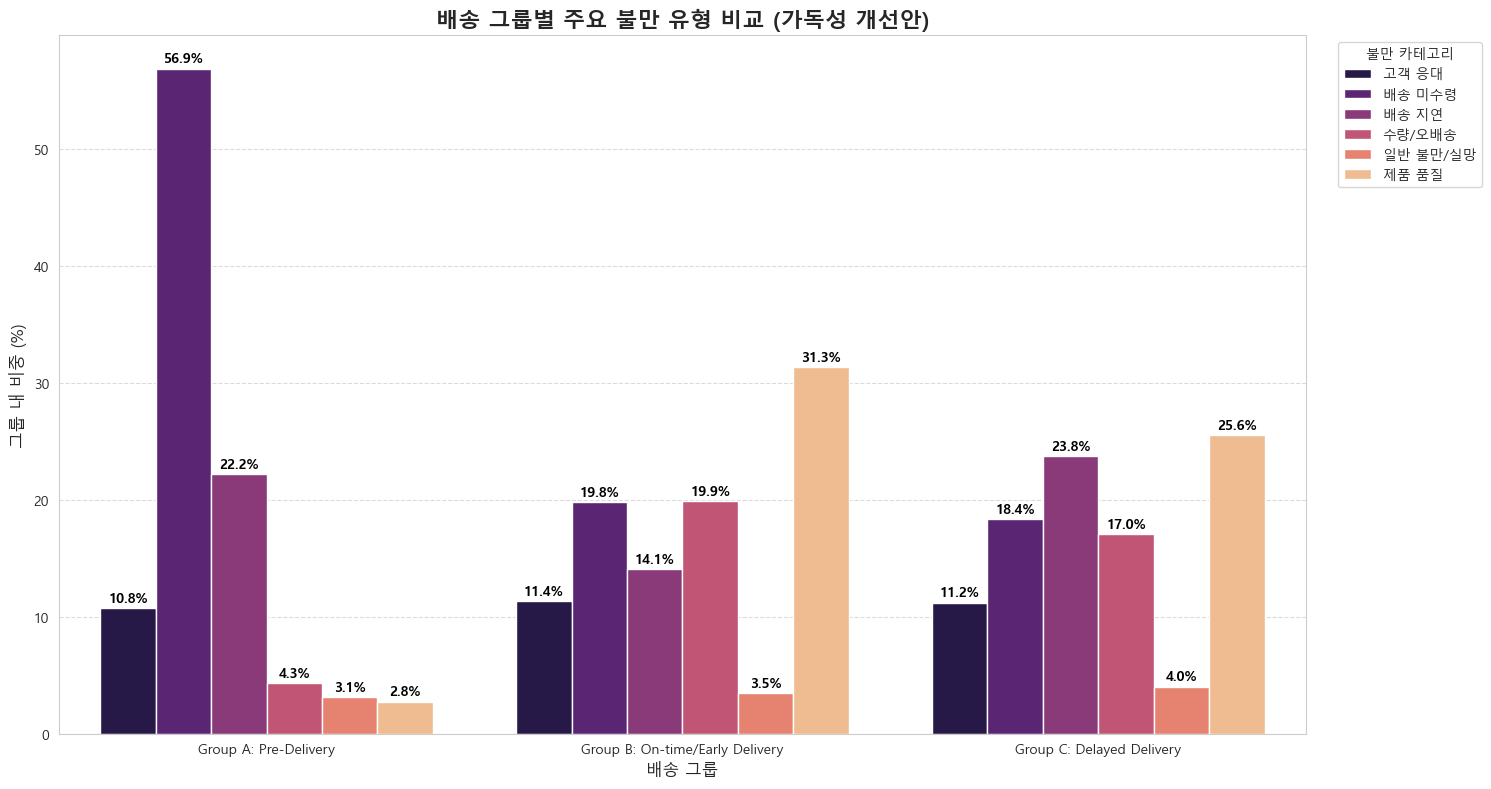

📊 미분류(기타) 비율: 44.1% (기타 항목은 그래프에서 제외하여 가독성을 높였습니다)


In [20]:
# ====================================
# [Step 2] 키워드 사전 대폭 확장 (미분류 최소화)
# ====================================

keyword_dict = {
    '배송 미수령': ['미수령', '안 옴', '안옴', '못 받음', '도착 안', '안 왔', '미배송', '받지 못', '아직도', '행방', '분실'],
    '수량/오배송': ['잘못', '다른 상품', '오배송', '누락', '부족', '개수', '수량', '다른게', '오베송', '부품', '구성품'],
    '제품 품질': ['품질', '고장', '파손', '불량', '쓰레기', '별로', '부서', '하자', '망가', '싸구려', '기스', '포장', '작동', '상태', '엉망', '스크래치', '가품'],
    '배송 지연': ['지연', '늦게', '느림', '기다', '함흥차사', '배송 속도', '기다림', '오래', '언제', '예정일'],
    '고객 응대': ['전화', '답변', '고개센터', '응대', '취소', '환불', '연락', '서비스', '불친절', '무시', '일방적', '채팅']
}

# '단순 불만' 카테고리를 추가하여 미분류를 줄임
general_bad_keywords = ['최악', '실망', '비추', '추천하지', '다시는', '사지 마세', '절대', '어이없', '황당']

def classify_complaint_v2(text):
    if pd.isna(text) or text == '': return '기타/미분류'
    
    # 1. 정의된 5개 주요 카테고리 매칭
    found_categories = [cat for cat, kws in keyword_dict.items() if any(kw in text for kw in kws)]
    
    # 2. 우선순위 적용
    category_priority = ['배송 미수령', '수량/오배송', '제품 품질', '배송 지연', '고객 응대']
    for priority_cat in category_priority:
        if priority_cat in found_categories: return priority_cat
        
    # 3. 주요 카테고리에 없지만 강력한 부정어가 있는 경우 '일반 불만'으로 분류
    if any(kw in text for kw in general_bad_keywords):
        return '일반 불만/실망'
        
    return '기타/미분류'

# 재분류 적용
df_final['complaint_category'] = df_final['message_ko'].apply(classify_complaint_v2)

# ====================================
# [Step 3-A] 개별 막대그래프(Grouped Bar)로 시각화
# ====================================
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 집계 (기타/미분류를 제외하고 보면 가독성이 더 올라갑니다)
plot_df = df_final[df_final['complaint_category'] != '기타/미분류']
analysis_df = plot_df.groupby(['delivery_group', 'complaint_category']).size().reset_index(name='count')

# 비율(%) 계산
group_totals = analysis_df.groupby('delivery_group')['count'].transform('sum')
analysis_df['percentage'] = (analysis_df['count'] / group_totals) * 100

# 시각화 실행 (Grouped Bar Chart)
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=analysis_df, x='delivery_group', y='percentage', hue='complaint_category', palette='magma')

plt.title('배송 그룹별 주요 불만 유형 비교 (가독성 개선안)', fontsize=16, fontweight='bold')
plt.ylabel('그룹 내 비중 (%)', fontsize=12)
plt.xlabel('배송 그룹', fontsize=12)
plt.legend(title='불만 카테고리', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 수치 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                    textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# 미분류 비율 확인용 출력
total_cnt = len(df_final)
unclass_cnt = len(df_final[df_final['complaint_category'] == '기타/미분류'])
print(f"📊 미분류(기타) 비율: {unclass_cnt/total_cnt*100:.1f}% (기타 항목은 그래프에서 제외하여 가독성을 높였습니다)")
